In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
from datetime import datetime
import re

class HurricaneSimulation:
    def __init__(self, hurdat2_file, wind_farm_lat, wind_farm_lon):
        self.hurdat2_file = hurdat2_file
        self.wind_farm_lat = wind_farm_lat
        self.wind_farm_lon = wind_farm_lon
        self.hurdat_df = self.parse_hurdat2()
    
    def parse_hurdat2(self):
        with open(self.hurdat2_file, 'r') as f:
            file_content = f.read()
        
        lines = file_content.strip().split('\n')
        data = []
        current_header = None
        
        for line in lines:
            if re.match(r'^[A-Z]{2}\d{6}', line):
                parts = line.split(',')
                basin_id = parts[0].strip()
                basin = basin_id[:2]
                cyclone_number = basin_id[2:4]
                year = basin_id[4:8]
                name = parts[1].strip()
                num_entries = int(parts[2].strip())
                current_header = {
                    'basin': basin,
                    'cyclone_number': cyclone_number,
                    'year': year,
                    'full_id': basin_id,
                    'name': name,
                    'num_entries': num_entries
                }
            else:
                if current_header:
                    parts = line.split(',')
                    date_str = parts[0].strip()
                    time_str = parts[1].strip()
                    year = int(date_str[0:4])
                    month = int(date_str[4:6])
                    day = int(date_str[6:8])
                    hour = int(time_str[0:2]) if time_str else 0
                    minute = int(time_str[2:4]) if len(time_str) >= 4 else 0
                    record_id = parts[2].strip()
                    status = parts[3].strip()
                    lat_str = parts[4].strip()
                    lon_str = parts[5].strip()
                    lat = float(lat_str[:-1]) * (1 if lat_str[-1] == 'N' else -1)
                    lon = float(lon_str[:-1]) * (-1 if lon_str[-1] == 'W' else 1)
                    max_wind = int(parts[6].strip()) if parts[6].strip() not in ['-999', ''] else None
                    min_pressure = int(parts[7].strip()) if parts[7].strip() not in ['-999', ''] else None
                    ne_34kt = int(parts[8].strip()) if len(parts) > 8 and parts[8].strip() not in ['-999', ''] else None
                    se_34kt = int(parts[9].strip()) if len(parts) > 9 and parts[9].strip() not in ['-999', ''] else None
                    sw_34kt = int(parts[10].strip()) if len(parts) > 10 and parts[10].strip() not in ['-999', ''] else None
                    nw_34kt = int(parts[11].strip()) if len(parts) > 11 and parts[11].strip() not in ['-999', ''] else None
                    ne_50kt = int(parts[12].strip()) if len(parts) > 12 and parts[12].strip() not in ['-999', ''] else None
                    se_50kt = int(parts[13].strip()) if len(parts) > 13 and parts[13].strip() not in ['-999', ''] else None
                    sw_50kt = int(parts[14].strip()) if len(parts) > 14 and parts[14].strip() not in ['-999', ''] else None
                    nw_50kt = int(parts[15].strip()) if len(parts) > 15 and parts[15].strip() not in ['-999', ''] else None
                    ne_64kt = int(parts[16].strip()) if len(parts) > 16 and parts[16].strip() not in ['-999', ''] else None
                    se_64kt = int(parts[17].strip()) if len(parts) > 17 and parts[17].strip() not in ['-999', ''] else None
                    sw_64kt = int(parts[18].strip()) if len(parts) > 18 and parts[18].strip() not in ['-999', ''] else None
                    nw_64kt = int(parts[19].strip()) if len(parts) > 19 and parts[19].strip() not in ['-999', ''] else None
                    rmw = int(parts[20].strip()) if len(parts) > 20 and parts[20].strip() not in ['-999', ''] else None
                    data.append({
                        'basin': current_header['basin'],
                        'cyclone_number': current_header['cyclone_number'],
                        'full_id': current_header['full_id'],
                        'storm_name': current_header['name'],
                        'year': year,
                        'month': month,
                        'day': day,
                        'hour': hour,
                        'minute': minute,
                        'record_id': record_id,
                        'status': status,
                        'latitude': lat,
                        'longitude': lon,
                        'max_wind': max_wind,
                        'min_pressure': min_pressure,
                        'ne_34kt_radius': ne_34kt,
                        'se_34kt_radius': se_34kt,
                        'sw_34kt_radius': sw_34kt,
                        'nw_34kt_radius': nw_34kt,
                        'ne_50kt_radius': ne_50kt,
                        'se_50kt_radius': se_50kt,
                        'sw_50kt_radius': sw_50kt,
                        'nw_50kt_radius': nw_50kt,
                        'ne_64kt_radius': ne_64kt,
                        'se_64kt_radius': se_64kt,
                        'sw_64kt_radius': sw_64kt,
                        'nw_64kt_radius': nw_64kt,
                        'radius_max_wind': rmw
                    })
        
        df = pd.DataFrame(data)
        df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
        return df
    
    def select_hurricane(self, storm_id):
        hurricane_data = self.hurdat_df[self.hurdat_df['full_id'] == storm_id]
        if not hurricane_data.empty:
            storm_name = hurricane_data['storm_name'].iloc[0]
            print(f"Selected Hurricane: {storm_id}, {storm_name}")
        return hurricane_data
    
    def filter_by_date(self, hurricane_data, month, day):
        return hurricane_data[(hurricane_data['month'] == month) & (hurricane_data['day'] == day)]
    
    def haversine_distance(self, lat1, lon1, lat2, lon2):
        from math import radians, sin, cos, sqrt, atan2
        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        distance = 6371 * c  # Earth radius in km
        return distance
    
    def calculate_distances(self, hurricane_data):
        return hurricane_data.apply(lambda row: self.haversine_distance(self.wind_farm_lat, self.wind_farm_lon, row['latitude'], row['longitude']), axis=1)
    
    def holland_wind_profile(self, r, vmax, rmax, B=1.5):
        return vmax * (rmax/r)**B * np.exp(1 - (rmax/r)**B)
    
    def calculate_wind_direction(self, lat1, lon1, lat2, lon2):
        from math import atan2, degrees
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        angle = atan2(dlat, dlon)
        bearing = (degrees(angle) + 360) % 360
        return bearing
    
    def estimate_wind_speed(self, hurricane_data, distances):
        if not distances.empty:
            closest_index = distances.idxmin()
            closest_record = hurricane_data.loc[closest_index]
            vmax = closest_record['max_wind']  # knots
            distance_km = distances[closest_index]
            rmax = 50  # typical value, can be adjusted
            wind_speed = self.holland_wind_profile(distance_km, vmax, rmax)
            wind_direction = self.calculate_wind_direction(closest_record['latitude'], closest_record['longitude'], self.wind_farm_lat, self.wind_farm_lon)
            return wind_speed, distance_km, vmax, wind_direction
        else:
            return None, None, None, None
    
    def plot_hurricane_tracks(self, hurricane_data, title='Hurricane Tracks'):
        fig = plt.figure(figsize=(15, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.add_feature(cfeature.STATES, linestyle=':')
        ax.set_extent([-100, -50, 10, 50], crs=ccrs.PlateCarree())

        # Add OpenStreetMap base map
        osm_tiles = cimgt.OSM()
        ax.add_image(osm_tiles, 8)

        # Plot hurricane path
        plt.plot(hurricane_data['longitude'], hurricane_data['latitude'], 
                 '-o', markersize=4, label=hurricane_data['storm_name'].iloc[0], transform=ccrs.PlateCarree())

        # Color points by intensity
        scatter = plt.scatter(hurricane_data['longitude'], hurricane_data['latitude'], 
                              c=hurricane_data['max_wind'], cmap='YlOrRd', 
                              transform=ccrs.PlateCarree())

        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Maximum Wind Speed (knots)')

        plt.title(title)
        plt.legend(loc='upper right')
        plt.grid(True)
        plt.show()
    
    def plot_wind_field(self, hurricane_data, rmax=50, B=1.5):
        lat_center = hurricane_data['latitude'].iloc[0]
        lon_center = hurricane_data['longitude'].iloc[0]
        
        lat_range = np.linspace(lat_center - 10, lat_center + 10, 200)
        lon_range = np.linspace(lon_center - 10, lon_center + 10, 200)
        
        lat_grid, lon_grid = np.meshgrid(lat_range, lon_range)
        
        wind_speeds = np.zeros_like(lat_grid)
        for i in range(lat_grid.shape[0]):
            for j in range(lat_grid.shape[1]):
                distance_km = self.haversine_distance(lat_center, lon_center, lat_grid[i, j], lon_grid[i, j])
                wind_speeds[i, j] = self.holland_wind_profile(distance_km, hurricane_data['max_wind'].iloc[0], rmax, B)
        
        fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
        
        # Add OpenStreetMap base map
        osm_tiles = cimgt.OSM()
        ax.add_image(osm_tiles, 8)
        
        contour = ax.contourf(lon_grid, lat_grid, wind_speeds, levels=np.linspace(0, hurricane_data['max_wind'].iloc[0], 20), cmap='YlOrRd', transform=ccrs.PlateCarree())
        plt.colorbar(contour, ax=ax, label='Wind Speed (knots)')
        ax.scatter(hurricane_data['longitude'], hurricane_data['latitude'], color='blue', label='Hurricane Track', transform=ccrs.PlateCarree())
        ax.scatter(self.wind_farm_lon, self.wind_farm_lat, color='red', label='Wind Farm', transform=ccrs.PlateCarree())
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.set_title('Hurricane Wind Field')
        ax.legend()
        plt.show()

    def estimate_wind_speed_over_time(self, hurricane_data):
        wind_speeds = []
        distances = []
        wind_directions = []
        
        for index, row in hurricane_data.iterrows():
            distance_km = self.haversine_distance(self.wind_farm_lat, self.wind_farm_lon, row['latitude'], row['longitude'])
            vmax = row['max_wind']  # knots
            rmax = 50  # typical value, can be adjusted
            wind_speed = self.holland_wind_profile(distance_km, vmax, rmax)
            wind_direction = self.calculate_wind_direction(row['latitude'], row['longitude'], self.wind_farm_lat, self.wind_farm_lon)
            
            wind_speeds.append(wind_speed)
            distances.append(distance_km)
            wind_directions.append(wind_direction)
        
        hurricane_data.loc[:, 'distance_km'] = distances
        hurricane_data.loc[:, 'wind_speed'] = wind_speeds
        hurricane_data.loc[:, 'wind_direction'] = wind_directions
        
        return hurricane_data

In [2]:
# Example usage
hurdat2_file = '/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Hurricane/NOAA HURDAT2/hurdat2-1851-2023-051124.txt'
wind_farm_lat = 38.27
wind_farm_lon = -74.68

In [3]:
simulation = HurricaneSimulation(hurdat2_file, wind_farm_lat, wind_farm_lon)

# # Prompt user for storm ID
# storm_id = input("Enter the storm ID (e.g., AL111959): ")

# Manually input the storm ID
storm_id = 'AL111959'  # Replace with the desired storm ID

Selected Hurricane: AL111959, JUDITH

During Hurricane AL111959:
Distance from wind farm: 1055.9 km
Maximum wind speed in hurricane: 75 knots
Estimated wind speed at wind farm: 2.1 knots
Wind direction at wind farm: 118.4 degrees


/var/folders/c9/zx22n7c1713_ck39lvd8nlx00000gn/T/ipykernel_5579/3433083386.py:232: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hurricane_data.loc[:, 'distance_km'] = distances
/var/folders/c9/zx22n7c1713_ck39lvd8nlx00000gn/T/ipykernel_5579/3433083386.py:233: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hurricane_data.loc[:, 'wind_speed'] = wind_speeds
/var/folders/c9/zx22n7c1713_ck39lvd8nlx00000gn/T/ipykernel_5579/3433083386.py:234: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slic

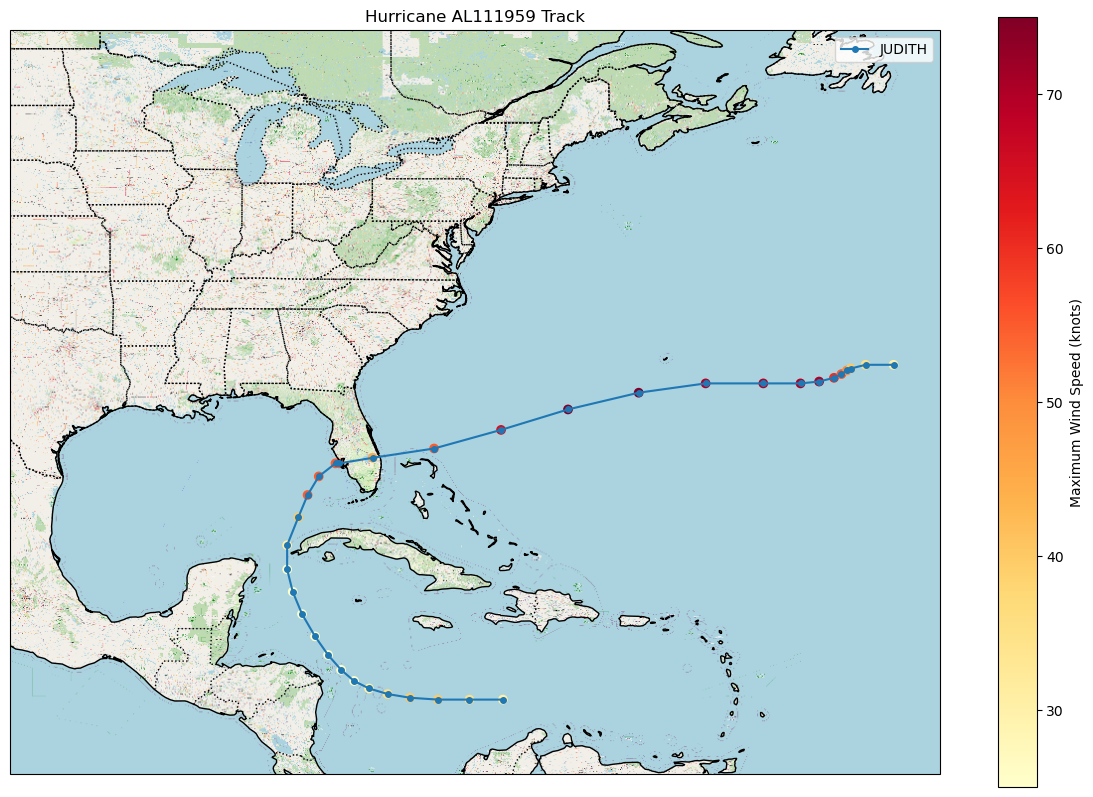

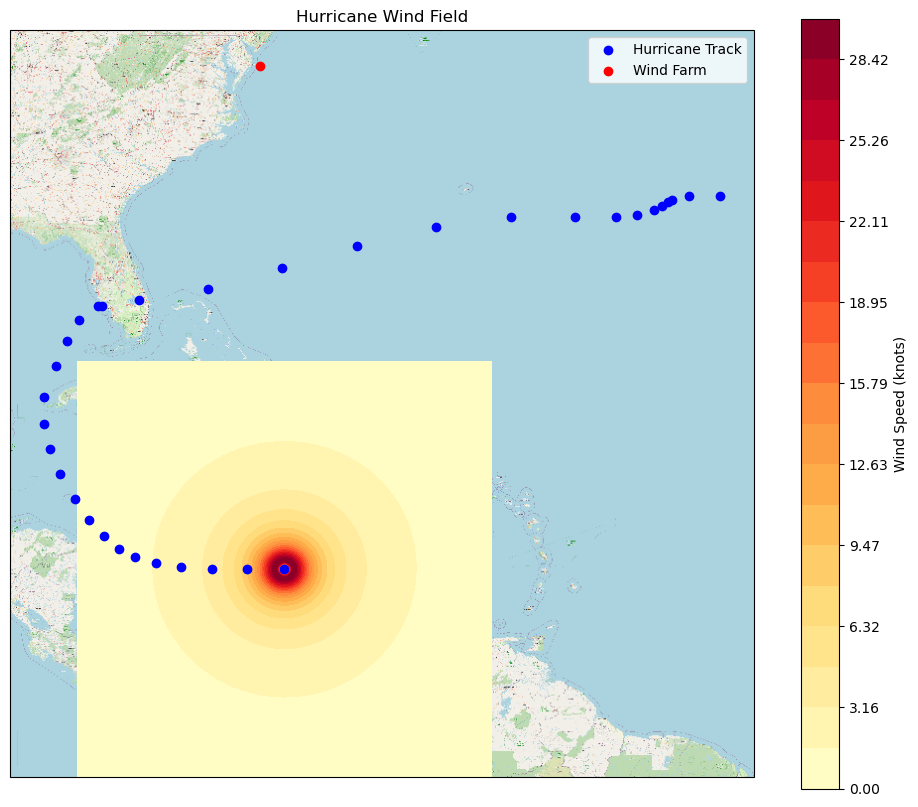

In [4]:
# Select hurricane data based on user input
hurricane_data = simulation.select_hurricane(storm_id)

# Use all data for the selected hurricane
hurricane_with_wind = simulation.estimate_wind_speed_over_time(hurricane_data)

# Print the calculated wind speed, distance, and direction
distances = simulation.calculate_distances(hurricane_data)
wind_speed, distance_km, vmax, wind_direction = simulation.estimate_wind_speed(hurricane_data, distances)
if wind_speed is not None:
    print(f"\nDuring Hurricane {storm_id}:")
    print(f"Distance from wind farm: {distance_km:.1f} km")
    print(f"Maximum wind speed in hurricane: {vmax} knots")
    print(f"Estimated wind speed at wind farm: {wind_speed:.1f} knots")
    print(f"Wind direction at wind farm: {wind_direction:.1f} degrees")

    if wind_speed > 48.6:
        print("WARNING: Wind speed exceeds typical turbine cut-out speed!")
else:
    print(f"No records found for Hurricane {storm_id}.")

# Plot hurricane tracks and wind field
simulation.plot_hurricane_tracks(hurricane_data, title=f'Hurricane {storm_id} Track')
simulation.plot_wind_field(hurricane_data)